# 02 - Exploratory Data Analysis (EDA)
Notebook ini membuat visualisasi tren kapasitas baterai terhadap siklus, SOH terhadap siklus, dan heatmap korelasi fitur sensor.

In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("baterai.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {DATA_PATH.resolve()}")

# Membaca dataset.
df = pd.read_csv(DATA_PATH)

# Mengagregasi data sensor menjadi level siklus untuk EDA.
cycle_eda = (
    df.groupby(["Battery_ID", "Cycle_Number"], as_index=False)
    .agg(
        Time_Seconds_max=("Time_Seconds", "max"),
        Voltage_V_mean=("Voltage_V", "mean"),
        Current_A_mean=("Current_A", "mean"),
        Temperature_C_mean=("Temperature_C", "mean"),
        Capacity_Ah=("Capacity_Ah", "mean"),
    )
    .sort_values(["Battery_ID", "Cycle_Number"])
)

# Membentuk State of Health (SOH).
cycle_eda["Initial_Capacity_Ah"] = cycle_eda.groupby("Battery_ID")["Capacity_Ah"].transform("first")
cycle_eda["SOH_Percent"] = cycle_eda["Capacity_Ah"] / cycle_eda["Initial_Capacity_Ah"] * 100

print(f"Ukuran data level siklus untuk EDA: {cycle_eda.shape[0]:,} baris")
display(cycle_eda.head())

Ukuran data level siklus untuk EDA: 2,769 baris


,Battery_ID,Cycle_Number,Time_Seconds_max,Voltage_V_mean,Current_A_mean,Temperature_C_mean,Capacity_Ah,Initial_Capacity_Ah,SOH_Percent
0,B0005,2,3690.234,3.529829,-1.818702,32.572328,1.856487,1.856487,100.000000
1,B0005,4,3672.344,3.537320,-1.817560,32.725235,1.846327,1.856487,99.452721
2,B0005,6,3651.641,3.543737,-1.816487,32.642862,1.835349,1.856487,98.861386
3,B0005,8,3631.563,3.543666,-1.825589,32.514876,1.835263,1.856487,98.856718
4,B0005,10,3629.172,3.542343,-1.826114,32.382349,1.834646,1.856487,98.823482


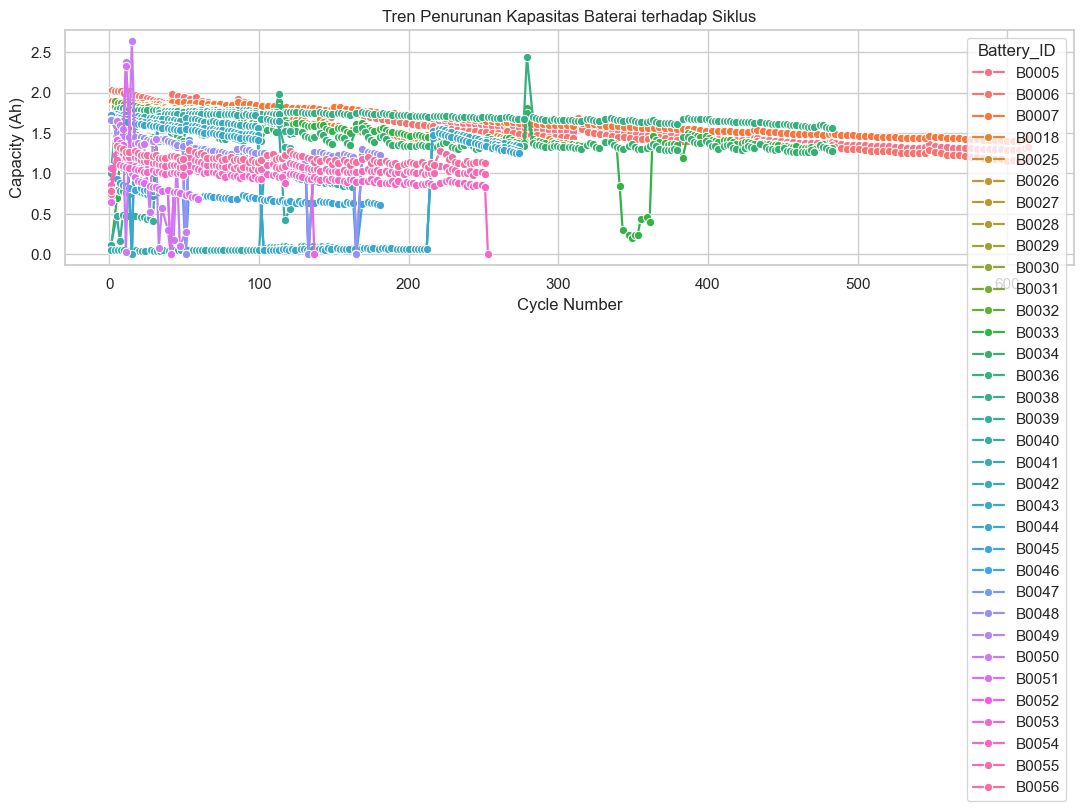

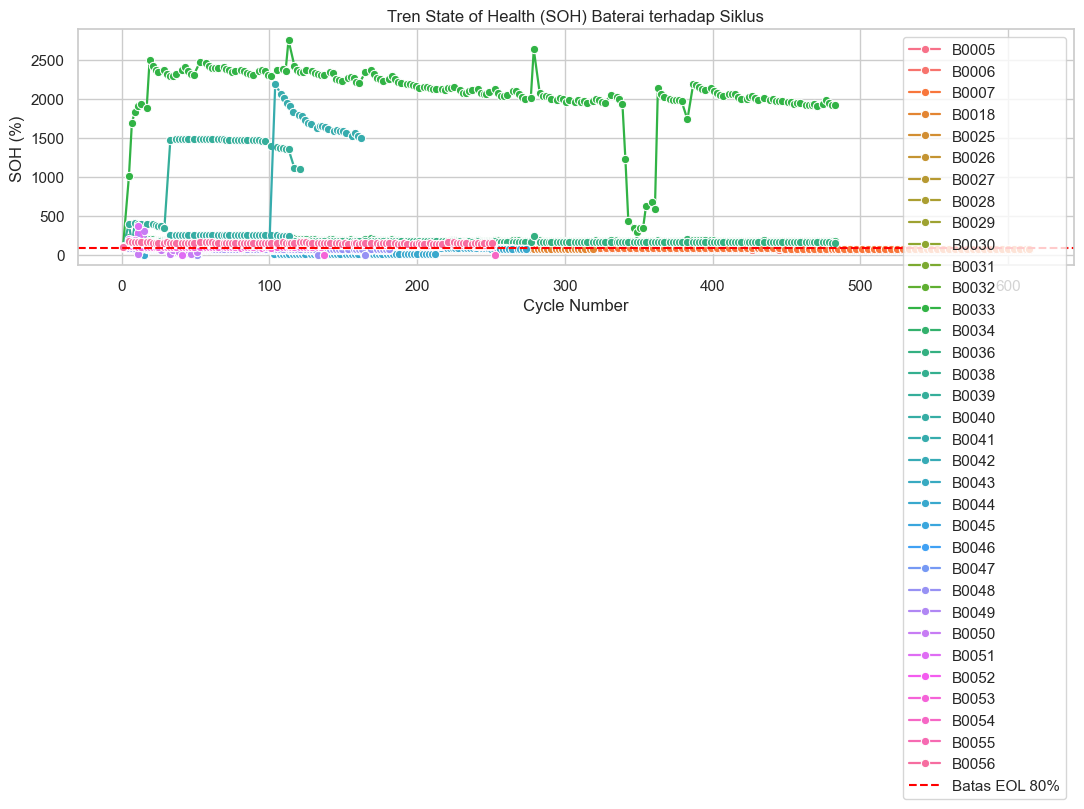

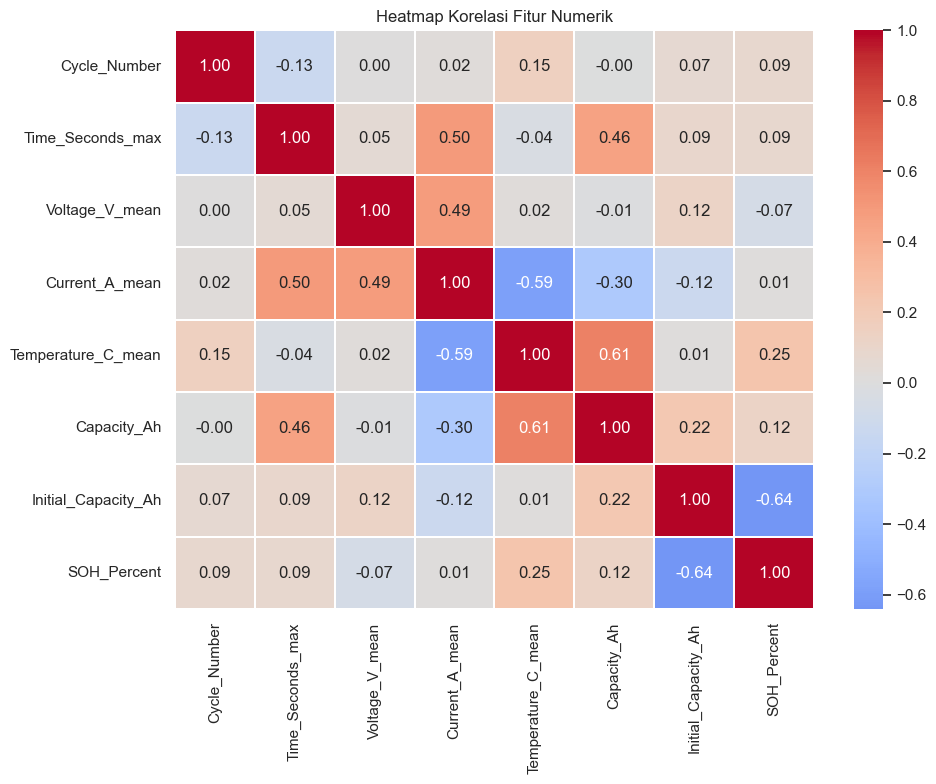

In [4]:
# Visualisasi tren penurunan kapasitas terhadap siklus.
plt.figure(figsize=(11, 6))
sns.lineplot(data=cycle_eda, x="Cycle_Number", y="Capacity_Ah", hue="Battery_ID", marker="o", linewidth=1.6)
plt.title("Tren Penurunan Kapasitas Baterai terhadap Siklus")
plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()
plt.show()

# Visualisasi SOH terhadap siklus.
plt.figure(figsize=(11, 6))
sns.lineplot(data=cycle_eda, x="Cycle_Number", y="SOH_Percent", hue="Battery_ID", marker="o", linewidth=1.6)
plt.axhline(80, color="red", linestyle="--", label="Batas EOL 80%")
plt.title("Tren State of Health (SOH) Baterai terhadap Siklus")
plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap korelasi antar fitur numerik.
plt.figure(figsize=(10, 8))
corr = cycle_eda.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.3)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

**Analisis Hasil**

EDA dilakukan untuk memahami pola degradasi baterai sebelum model dibangun. Data sensor mentah diagregasi ke level siklus agar tren penurunan kapasitas dapat diamati dengan jelas. Visualisasi kapasitas terhadap `Cycle_Number` menunjukkan bahwa kapasitas baterai cenderung menurun seiring bertambahnya siklus pemakaian. Visualisasi SOH memperlihatkan kondisi kesehatan baterai dibandingkan kapasitas awal, sedangkan heatmap korelasi membantu melihat hubungan antara siklus, fitur sensor, kapasitas, dan indikator kesehatan baterai.